In [1]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# Plant Disease Detection using EfficientNet-B4
# Transfer Learning + Fine Tuning
# GPU Accelerated Training using TensorFlow
# ============================================================

In [3]:
!pip install matplotlib seaborn scikit-learn pandas

In [4]:
# ============================================================
# Import Required Libraries
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [5]:
# ============================================================
# Verify GPU Availability
# ============================================================

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# ============================================================
# Dataset Paths
# ============================================================

train_path = "dataset/train"
valid_path = "dataset/valid"
test_path = "dataset/test"

In [7]:
# ============================================================
# Load Training, Validation and Test Dataset
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 8

# Training Data Generator with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

# Validation/Test Data Generator
valid_datagen = ImageDataGenerator(rescale=1./255)

# Load Training Dataset
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Load Validation Dataset
valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Load Test Dataset
test_data = valid_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 14362 images belonging to 15 classes.
Found 3080 images belonging to 15 classes.
Found 3087 images belonging to 15 classes.


In [8]:
# ============================================================
# Build EfficientNet-B4 Model
# ============================================================

# Load EfficientNetB4 Base Model
base_model = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Enable Fine Tuning
base_model.trainable = True

# Create Sequential Model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(15, activation='softmax')
])

print("EfficientNet-B4 Model Built Successfully!")

EfficientNet-B4 Model Built Successfully!


In [9]:
# ============================================================
# Compile Model
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [10]:
# ============================================================
# Define Training Callbacks
# ============================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="models/best_weights.h5",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

print("Callbacks Created Successfully!")

Callbacks Created Successfully!


In [11]:
# ============================================================
# Train Model (GPU Test Run)
# ============================================================

history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/30
1796/1796 [==============================] - ETA: 0s - loss: 0.7589 - accuracy: 0.7686
Epoch 1: val_accuracy improved from -inf to 0.15455, saving model to models\best_weights.h5
1796/1796 [==============================] - 323s 141ms/step - loss: 0.7589 - accuracy: 0.7686 - val_loss: 3.1118 - val_accuracy: 0.1545 - lr: 1.0000e-04
Epoch 2/30
1796/1796 [==============================] - ETA: 0s - loss: 0.2227 - accuracy: 0.9324
Epoch 2: val_accuracy improved from 0.15455 to 0.66786, saving model to models\best_weights.h5
1796/1796 [==============================] - 253s 141ms/step - loss: 0.2227 - accuracy: 0.9324 - val_loss: 1.2262 - val_accuracy: 0.6679 - lr: 1.0000e-04
Epoch 3/30
1796/1796 [==============================] - ETA: 0s - loss: 0.1516 - accuracy: 0.9545
Epoch 3: val_accuracy did not improve from 0.66786
1796/1796 [==============================] - 252s 141ms/step - loss: 0.1516 - accuracy: 0.9545 - val_loss: 1.7753 - val_accuracy: 0.6351 - lr: 1.0000e-04
Epoch 

In [12]:
# ============================================================
# Final Model Evaluation
# ============================================================

test_loss, test_accuracy = model.evaluate(test_data)

print("Final Test Accuracy :", test_accuracy)
print("Final Test Loss :", test_loss)

386/386 [==============================] - 14s 35ms/step - loss: 0.0187 - accuracy: 0.9955
Final Test Accuracy : 0.9954648613929749
Final Test Loss : 0.018697237595915794


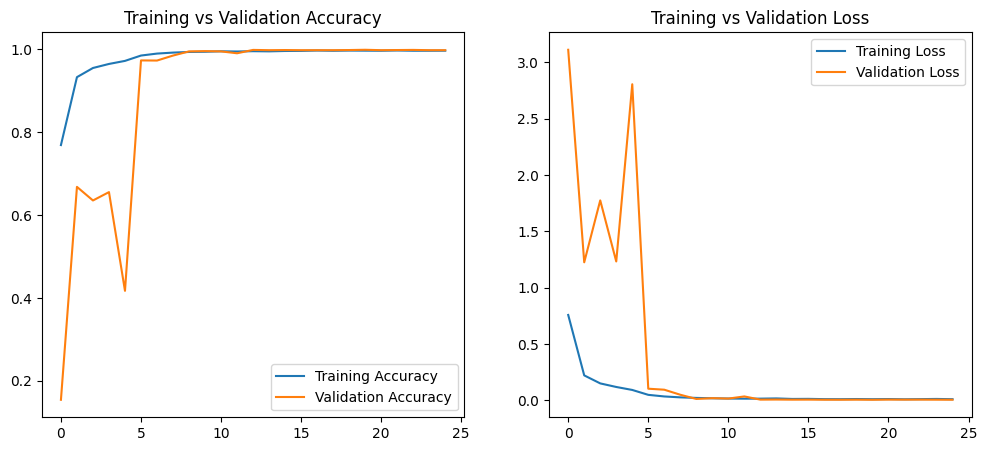

In [13]:
# ============================================================
# Plot Accuracy and Loss Graphs
# ============================================================

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Accuracy Graph
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')

# Loss Graph
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')

plt.show()

In [14]:
# ============================================================
# Generate Predictions
# ============================================================

predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

class_labels = list(test_data.class_indices.keys())

386/386 [==============================] - 14s 33ms/step


In [15]:
# ============================================================
# Classification Metrics
# ============================================================

accuracy = accuracy_score(true_classes, predicted_classes)

precision = precision_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

recall = recall_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

f1 = f1_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.9954648526077098
Precision : 0.9955335307525083
Recall : 0.9954648526077098
F1 Score : 0.9954754139562219


In [16]:
# ============================================================
# Classification Report
# ============================================================

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00       150
                     Pepper__bell___healthy       1.00      0.99      0.99       222
                      Potato___Early_blight       1.00      1.00      1.00       150
                       Potato___Late_blight       1.00      0.99      0.99       150
                           Potato___healthy       0.92      1.00      0.96        23
                      Tomato_Bacterial_spot       1.00      1.00      1.00       317
                        Tomato_Early_blight       0.99      0.98      0.98       150
                         Tomato_Late_blight       0.99      0.99      0.99       285
                           Tomato_Leaf_Mold       0.99      1.00      1.00       143
                  Tomato_Septoria_leaf_spot       1.00      1.00      1.00       266
Tomato_Spider_mites_Two_spotted_spider_mite       0.99      1.00

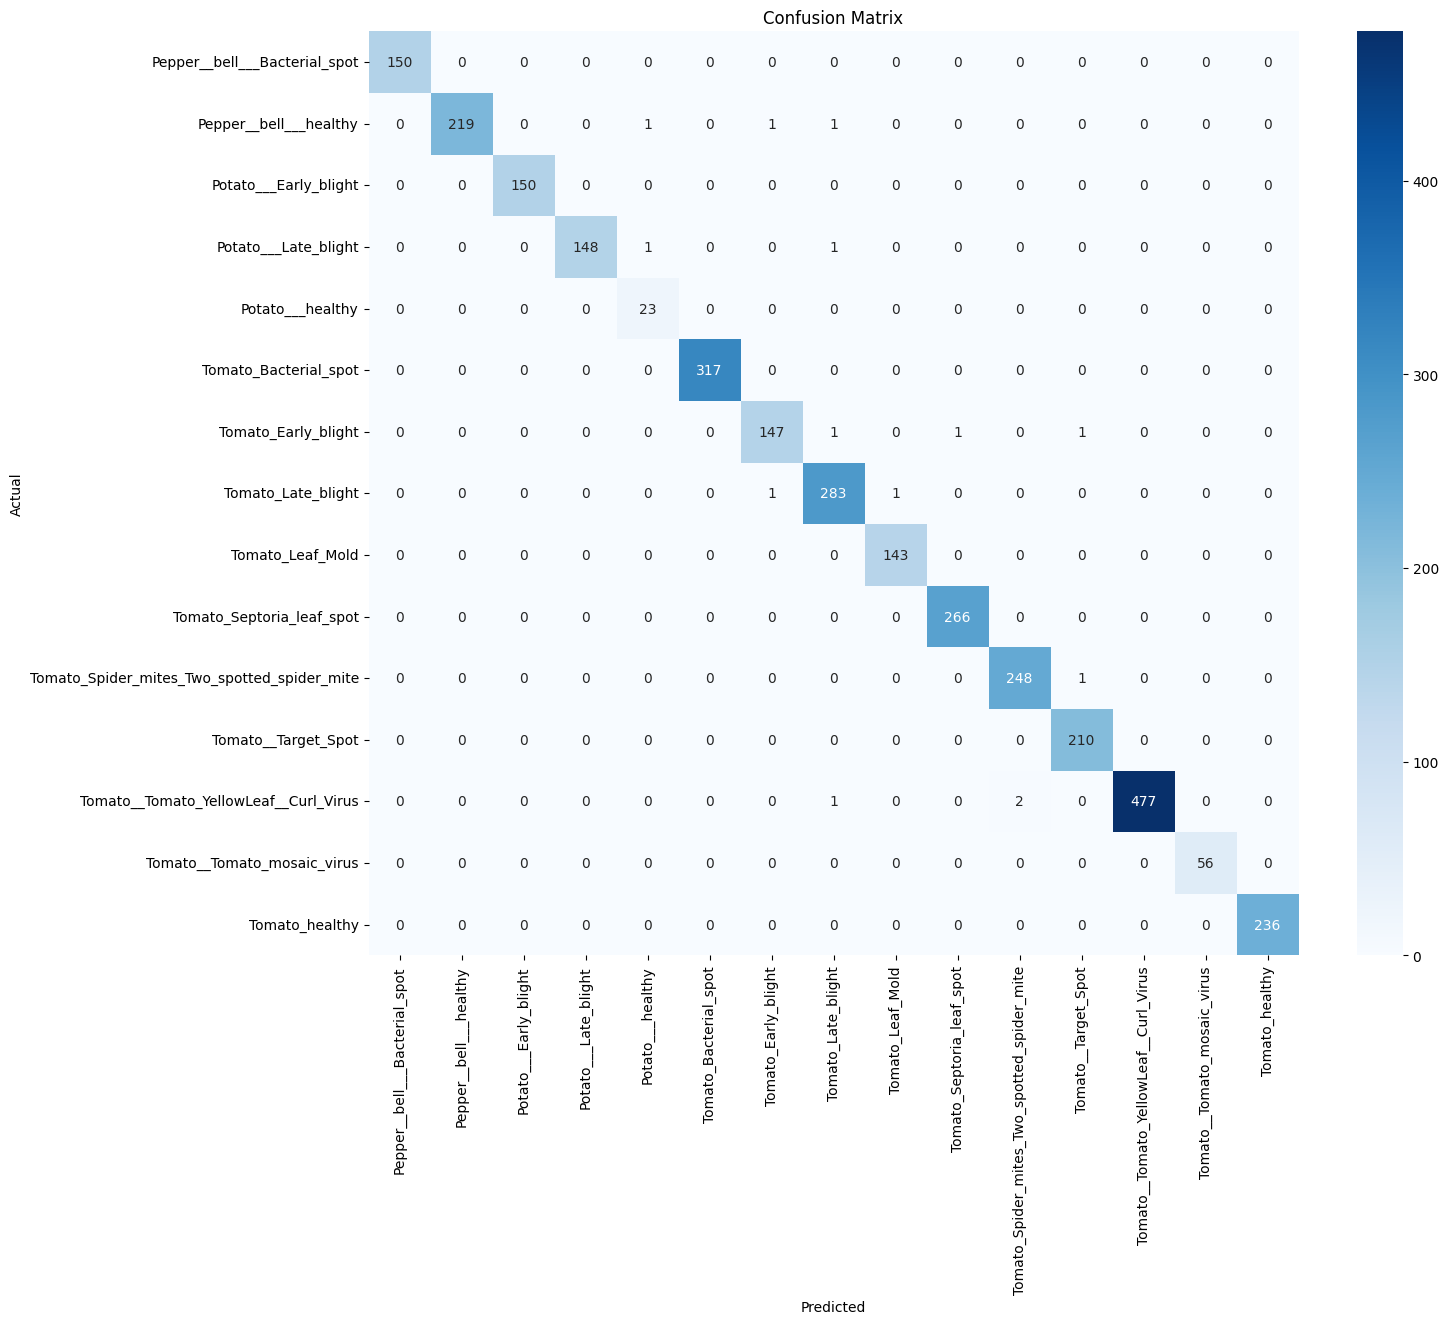

In [17]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

1/1 [==============================] - 0s 32ms/step
Prediction Correct ✅
Actual Class : Tomato__Target_Spot
Predicted Class : Tomato__Target_Spot


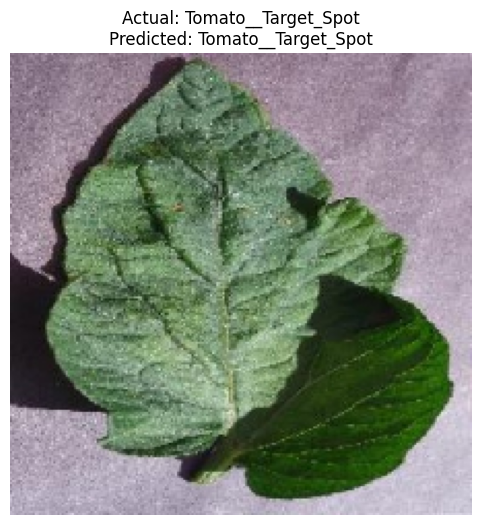

In [19]:
# ============================================================
# Predict Single Test Image with Actual Label
# ============================================================

import random
import os
from tensorflow.keras.preprocessing import image

# Select Random Test Image
test_image_path = random.choice(test_data.filepaths)

# Actual Class Name
actual_class = os.path.basename(os.path.dirname(test_image_path))

# Load Image
img = image.load_img(test_image_path, target_size=(224,224))

# Preprocess Image
img_array = image.img_to_array(img) / 255.0

img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

predicted_class = class_labels[np.argmax(prediction)]

# Display Image
plt.figure(figsize=(6,6))
plt.imshow(img)

plt.title(
    f"Actual: {actual_class}\nPredicted: {predicted_class}",
    fontsize=12
)

plt.axis('off')

# Correct or Wrong
if actual_class == predicted_class:
    print("Prediction Correct ✅")
else:
    print("Prediction Wrong ❌")

print("Actual Class :", actual_class)
print("Predicted Class :", predicted_class)

plt.show()

1/1 [==============================] - 0s 39ms/step
Prediction Correct ✅
Actual Class : Pepper__bell___healthy
Predicted Class : Pepper__bell___healthy


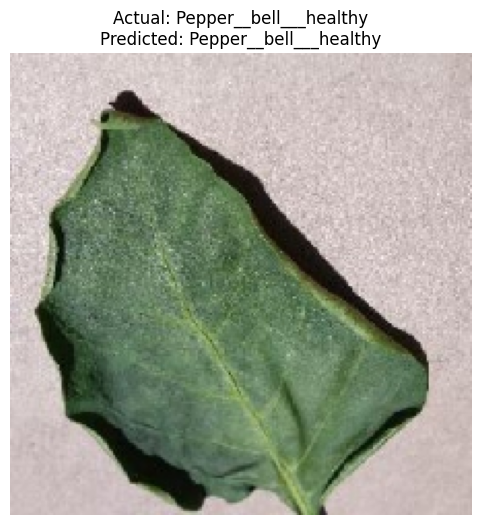

In [20]:
# ============================================================
# Predict Single Training Image
# ============================================================

import random
import os
from tensorflow.keras.preprocessing import image

# Select Random Training Image
train_image_path = random.choice(train_data.filepaths)

# Actual Class Name
actual_class = os.path.basename(os.path.dirname(train_image_path))

# Load Image
img = image.load_img(train_image_path, target_size=(224,224))

# Preprocess Image
img_array = image.img_to_array(img) / 255.0

img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

predicted_class = class_labels[np.argmax(prediction)]

# Display Image
plt.figure(figsize=(6,6))
plt.imshow(img)

plt.title(
    f"Actual: {actual_class}\nPredicted: {predicted_class}",
    fontsize=12
)

plt.axis('off')

# Correct/Wrong
if actual_class == predicted_class:
    print("Prediction Correct ✅")
else:
    print("Prediction Wrong ❌")

print("Actual Class :", actual_class)
print("Predicted Class :", predicted_class)

plt.show()